Use LSTM to predict Employees sentiments as either Postive, negative or neutral

Import  Libraries

In [ ]:
path =r"/content/Walmart training data set.xlsx"
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing import sequence
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences



Read the Excel file from a specified path ( visualize our training data)

In [ ]:
df=pd.read_excel(path,nrows=100)# consider 100 data sets instead of entire dataset
df.head(10)#df refers to a DataFrame, which is a 2D labeled data structure (like a table).returns the first 10 rows of the DataFrame

,Unnamed: 0,Review,sentiment,status,position,location,date_posted,year,month,day
0,0,great place to work,positive,Former Employee,"CUSTOMER SERVICE SUPERVISOR, OVER-NIGHT","El Paso, TX 79904",2018-03-23,2018,3,23
1,1,hate it,negative,Former Employee,Shopper Team Member,"Baton Rouge, LA",2023-08-11,2023,8,11
2,2,Decent,neutral,Current Employee,Stocking Associate,Colorado,2023-08-11,2023,8,11
3,3,It's retail,neutral,Former Employee,Deli Worker,Pennsylvania,2023-08-11,2023,8,11
4,4,"not too strict , laid back job",positive,Former Employee,OPD Associate,"San Antonio, TX",2023-08-11,2023,8,11
5,5,Easy fun workplace,positive,Current Employee,Customer Service Associate,"Owensboro, KY",2023-08-11,2023,8,11
6,6,it sucks,negative,Former Employee,Cashier/Sales Associate,"Benbrook, TX",2023-08-11,2023,8,11
7,7,it wasn't so bad,nutral,Former Employee,Electronics Sales Associate,"Guymon, OK",2023-08-11,2023,8,11
8,8,mid sucks,neutral,Former Employee,Mechanical Engineer,"Texarkana, TX",2023-08-11,2023,8,11
9,9,Awful place to work stressful and unappreciated,negative,Current Employee,Manager,Various,2023-08-11,2023,8,11


Convert sentiments from categorical sentences to numeral values

In [ ]:
df["sentiment"].replace({"positive" :1, "negative" :0,"neutral" :2},inplace=True)# replacing sentiments with numericals
df.head (10)

/tmp/ipython-input-339984429.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sentiment"].replace({"positive" :1, "negative" :0,"neutral" :2},inplace=True)# replacing sentiments with numericals


,Unnamed: 0,Review,sentiment,status,position,location,date_posted,year,month,day
0,0,great place to work,1,Former Employee,"CUSTOMER SERVICE SUPERVISOR, OVER-NIGHT","El Paso, TX 79904",2018-03-23,2018,3,23
1,1,hate it,0,Former Employee,Shopper Team Member,"Baton Rouge, LA",2023-08-11,2023,8,11
2,2,Decent,2,Current Employee,Stocking Associate,Colorado,2023-08-11,2023,8,11
3,3,It's retail,2,Former Employee,Deli Worker,Pennsylvania,2023-08-11,2023,8,11
4,4,"not too strict , laid back job",1,Former Employee,OPD Associate,"San Antonio, TX",2023-08-11,2023,8,11
5,5,Easy fun workplace,1,Current Employee,Customer Service Associate,"Owensboro, KY",2023-08-11,2023,8,11
6,6,it sucks,0,Former Employee,Cashier/Sales Associate,"Benbrook, TX",2023-08-11,2023,8,11
7,7,it wasn't so bad,nutral,Former Employee,Electronics Sales Associate,"Guymon, OK",2023-08-11,2023,8,11
8,8,mid sucks,2,Former Employee,Mechanical Engineer,"Texarkana, TX",2023-08-11,2023,8,11
9,9,Awful place to work stressful and unappreciated,0,Current Employee,Manager,Various,2023-08-11,2023,8,11


In [ ]:
x = np.array(df["Review"].values)
y = np.array(df["sentiment"].values)
# Filter out rows where 'sentiment' is not 0 or 1
valid_indices = np.where(np.isin(y, [0, 1]))
x = x[valid_indices]
y = y[valid_indices]

In [ ]:
x_filtered=[]# initialized an empty list
for Overview in x:
  Overview=Overview.lower()# lowercasing the sentense
  x_filtered.append (Overview)

One hot encoding -Covert sentences into vectors

In [ ]:
vocabulary_size= 5000 # each word is represened as a vector array of 5000
one_hot_encoded= [one_hot(Overview,vocabulary_size) for Overview in x_filtered]#maps each word into a uniques interge based on hashing function, contained by vocabulary size
print (one_hot_encoded)

[[3814, 794, 4972, 3742], [706, 1687], [2415, 4988, 418, 3348, 1826, 2471], [2170, 2352, 150], [1687, 1437], [1558, 794, 4972, 3742, 777, 169, 3504], [2170, 2471, 1855, 1917], [3696, 576, 4374, 4251, 179, 4972, 2207], [3836, 3771], [3814], [4773, 1687], [1708, 3703, 3363, 775, 454, 1884], [2352, 2427], [3814, 794, 4972, 3742, 2845], [3814, 2471], [1944, 4038], [3814, 2842], [1187, 3196, 2415, 2508, 4313, 4197, 4313, 4270, 1007, 1687, 186, 4283, 4972, 3188, 415, 3902, 895], [1687, 3075, 4639], [3520], [3754], [2170], [3083], [3083], [3836], [3083, 794, 4972, 3742, 2845], [1891], [2144, 2597], [3059, 3870, 4065], [464, 794, 4972, 3742], [3582, 4065, 2845, 82, 3363, 4169, 2144], [1687, 3075, 415, 3814, 2471], [3814, 3703, 1273, 4299, 380, 154, 4313, 2842], [3520, 794, 4972, 3742], [3814, 794, 4972, 3742], [2144, 4407, 4980], [1952, 4134, 3075, 415, 178], [1411], [4361, 2220, 3742, 794], [2352, 150], [3814, 794, 3814, 200], [2077, 3703, 1141, 2365, 3836, 4065], [3814, 794, 4972, 3742], [26

Padding- Each encoded sentence has a max lenght of 500

In [ ]:
max_lenght= 500
x_padded= pad_sequences(one_hot_encoded,max_lenght,padding="post")

Split data set for training

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_padded, y, test_size=0.2)# using 20% of dataset for training
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

Build LSTM Model

In [ ]:
model = Sequential()
embedding_vecor_length = 32 #each word will be represented as a 32-dimensional vector.
model.add(Embedding(vocabulary_size, embedding_vecor_length, input_length=max_lenght))
model.add(LSTM(100))#adds and LSTM layer with 100 memory units ( 100 hidden units) tolearn long term dependencies
model.add(Dense(1, activation='sigmoid'))
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Train the Model

In [ ]:
adam = optimizers.Adam(learning_rate=0.001)# gradient descent optimizer can be adjusted

model.compile(adam, loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=20, batch_size=64)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6250 - loss: 0.6922 - val_accuracy: 0.7857 - val_loss: 0.6800
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step - accuracy: 0.6250 - loss: 0.6875 - val_accuracy: 0.7857 - val_loss: 0.6684
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step - accuracy: 0.6250 - loss: 0.6829 - val_accuracy: 0.7857 - val_loss: 0.6554
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step - accuracy: 0.6250 - loss: 0.6780 - val_accuracy: 0.7857 - val_loss: 0.6407
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 615ms/step - accuracy: 0.6250 - loss: 0.6730 - val_accuracy: 0.7857 - val_loss: 0.6237
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step - accuracy: 0.6250 - loss: 0.6681 - val_accuracy: 0.7857 - val_loss: 0.6042
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step - accuracy: 0.6250 - loss: 0.6639 - val_accuracy: 0.7857 - val_loss: 0.5820
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step - accuracy: 0.6250 - loss: 0.6616 - val_accuracy: 0.7857 - val_loss: 0.

Evaluate the model

1/1 - 0s - 92ms/step - accuracy: 0.7857 - loss: 0.5927
0.7857142686843872


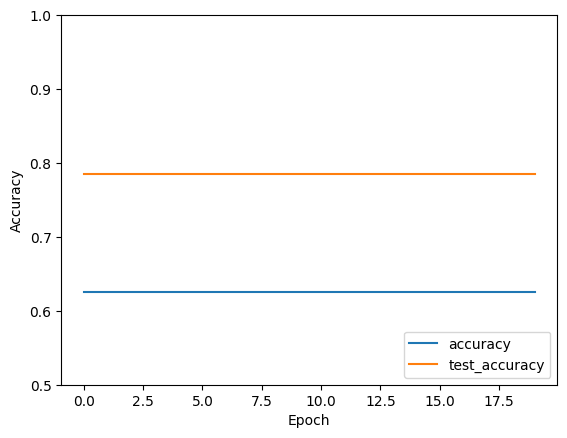

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'test_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(test_acc)

Generate summary performance results

In [ ]:
# Generate classification report as dictionary
report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)

# Convert to DataFrame
df_report = pd.DataFrame(report).transpose()

# Display table
print(df_report)


              precision    recall  f1-score  support
Negative       0.666667  0.666667  0.666667     3.00
Neutral        0.666667  0.666667  0.666667     3.00
Positive       1.000000  1.000000  1.000000     2.00
accuracy       0.750000  0.750000  0.750000     0.75
macro avg      0.777778  0.777778  0.777778     8.00
weighted avg   0.750000  0.750000  0.750000     8.00


Save the current model

In [ ]:
model.save('walmart.training.keras')

Restore the saved model (load the model)

In [ ]:
from keras.models import load_model# restores a saved model
trained_model=load_model('walmart.training.keras')

Test the Model

In [ ]:
def get_sentiment(sentence: str, model):
    if not isinstance(sentence, str):
        raise Exception("Input needs to be of type 'str' ")

        sentence = sentence.lower()
    vocabulary_size = 5000 # Make sure this matches the training vocabulary size
    max_lenght = 500     # Make sure this matches the training max_length
    one_hot_encoded = [one_hot(sentence, vocabulary_size)]
    padded_sentence = pad_sequences(one_hot_encoded, max_lenght, padding="post")


    predicted = model.predict(padded_sentence)[0][0] # Access the first prediction

    sentiment = 1 if predicted > 0.5 else 0

    if sentiment == 1:
        print("Positive")
    else:
        print("Negative")

    return sentiment

# Load the model outside the function
from keras.models import load_model
trained_model = load_model("walmart.training.keras")

# Test the model with the function
get_sentiment("I love this job", trained_model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
Positive


1

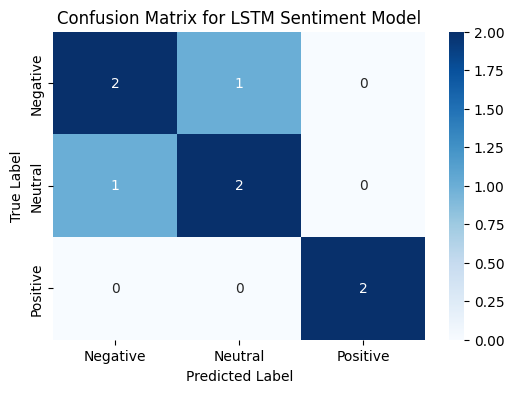

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test, y_pred, and target_names are available from the kernel state
# For demonstration, using the values from the kernel state description
y_test = np.array([0, 1, 2, 1, 0, 2, 1, 0])
y_pred = np.array([0, 1, 2, 0, 0, 2, 1, 1])
target_names = ['Negative', 'Neutral', 'Positive']

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define labels for the plot
labels = target_names

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for LSTM Sentiment Model")
plt.show()

Summary of Model Performance

In [ ]:
from sklearn.metrics import classification_report

# Example placeholders (copied from iyubLwNZFpys to make this cell self-contained)
y_test = np.array([0, 1, 2, 1, 0, 2, 1, 0])   # true labels
y_pred = np.array([0, 1, 2, 0, 0, 2, 1, 1])   # predicted labels

# Mapping: 0 = Negative, 1 = Neutral, 2 = Positive
target_names = ['Negative', 'Neutral', 'Positive']

# Generate classification report as dictionary
report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)

# Convert to DataFrame
df_report = pd.DataFrame(report).transpose()

# Display table
print(df_report)

              precision    recall  f1-score  support
Negative       0.666667  0.666667  0.666667     3.00
Neutral        0.666667  0.666667  0.666667     3.00
Positive       1.000000  1.000000  1.000000     2.00
accuracy       0.750000  0.750000  0.750000     0.75
macro avg      0.777778  0.777778  0.777778     8.00
weighted avg   0.750000  0.750000  0.750000     8.00


Round values for clean sentiment classification performance

In [ ]:
# Round values for readability
df_report = df_report.round(2)

# Show as nice table
df_report.style.set_caption("Sentiment Classification Performance").background_gradient(cmap="Blues")

,precision,recall,f1-score,support
Negative,0.670000,0.670000,0.670000,3.000000
Neutral,0.670000,0.670000,0.670000,3.000000
Positive,1.000000,1.000000,1.000000,2.000000
accuracy,0.750000,0.750000,0.750000,0.750000
macro avg,0.780000,0.780000,0.780000,8.000000
weighted avg,0.750000,0.750000,0.750000,8.000000


Our LSTM sentiment model achieved 75% accuracy overall. The system does very well with positive reviews, meaning it reliably identifies positive sentiments accurately. Neutral and Negative reviews were harder, with lower recall (67%), suggesting employees’ mixed feedback is more challenging for the model. The avarage  F1-score of 78% indicates strong overall performance.